# Functional Bayesian Networks with pgmpy

This notebook demonstrates how to work with Functional Bayesian Networks (FBNs) using pgmpy. We'll cover:
1. Defining a Functional BN
2. Simulating data from it
3. Fitting a functional BN

Functional BNs use deterministic functions instead of probability tables to define relationships between variables.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pgmpy.models import FunctionalBayesianNetwork
from pgmpy.factors.hybrid import FunctionalCPD
from pgmpy.sampling import BayesianModelSampling
from pgmpy.inference import VariableElimination
import random
import torch
import pyro.distributions as dist
import pyro

print("Libraries imported successfully!")

/home/sailesh/ESOC/pgmpy/pgmpy/factors/base.py:80: SyntaxWarning: invalid escape sequence '\s'
  """
/home/sailesh/ESOC/pgmpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sailesh/ESOC/pgmpy/pgmpy/models/SEM.py:447: SyntaxWarning: invalid escape sequence '\g'
  """
/home/sailesh/ESOC/pgmpy/pgmpy/inference/ExactInference.py:787: SyntaxWarning: invalid escape sequence '\s'
  """


Libraries imported successfully!


/home/sailesh/ESOC/pgmpy/pgmpy/inference/mplp.py:101: SyntaxWarning: invalid escape sequence '\{'
  """


## 1. Defining a Functional Bayesian Network

Let's create a simple example: a student's performance model where:
- **Intelligence** (I): Root node with random distribution
- **StudyHours** (S): Root node with random distribution  
- **Grade** (G): Functionally determined by Intelligence and StudyHours
- **Recommendation** (R): Functionally determined by Grade

In FunctionalBayesianNetwork, ALL nodes must have FunctionalCPDs, including root nodes.

In [13]:
# Define the network structure
model = FunctionalBayesianNetwork([('Intelligence', 'Grade'), 
                                  ('StudyHours', 'Grade'),
                                  ('Grade', 'Recommendation')])

print("Functional Bayesian Network structure:")
print(f"Nodes: {list(model.nodes())}")
print(f"Edges: {list(model.edges())}")

Functional Bayesian Network structure:
Nodes: ['Intelligence', 'Grade', 'StudyHours', 'Recommendation']
Edges: [('Intelligence', 'Grade'), ('Grade', 'Recommendation'), ('StudyHours', 'Grade')]


In [ ]:
# BENEFIT 1: Mixed variable types - Categorical Intelligence
def intelligence_distribution(parents):
    """
    Intelligence as categorical variable: Low(0), Medium(1), High(2)
    This shows we can handle categorical variables
    """
    probs = pyro.param(
        "p_intelligence", 
        torch.tensor([0.3, 0.5, 0.2], dtype=torch.float),
        constraint=dist.constraints.simplex
    )
    return dist.Categorical(probs=probs)

# BENEFIT 1: Mixed variable types - Continuous StudyHours
def study_hours_distribution(parents):
    """
    Study hours as continuous variable (0-12 hours per day)
    Uses Gamma distribution for realistic study time modeling
    (Traditional tabular CPDs cannot handle continuous variables!)
    """
    # Gamma distribution with shape=2, rate=0.4 gives realistic study hours
    return dist.Gamma(2.0, 0.4)

# Create FunctionalCPDs for root nodes
cpd_intelligence = FunctionalCPD(
    variable='Intelligence',
    fn=intelligence_distribution
)

cpd_study = FunctionalCPD(
    variable='StudyHours',
    fn=study_hours_distribution,
)

print("Root node Functional CPDs defined:")


Root node Functional CPDs defined:


In [ ]:
# This showcases the power of functional BNs
def compute_grade(parents):
    """
    Grade (0-100) with more controlled realistic relationships:
    - Intelligence provides base performance level
    - Study hours add improvement with diminishing returns
    - Reasonable variance for probabilistic outcomes
    """
    intelligence = parents["Intelligence"]
    study_hours = parents["StudyHours"]

    if not torch.is_tensor(intelligence):
        intelligence = torch.tensor(intelligence, dtype=torch.float)
    if not torch.is_tensor(study_hours):
        study_hours = torch.tensor(study_hours, dtype=torch.float)
    
    # More controlled base grades: Low=50, Average=65, High=75
    base_grade = 50.0 + intelligence * 12.5  # Low:50, Avg:62.5, High:75
    
    # Study hours with diminishing returns (capped at reasonable improvement)
    # Max 25 points improvement from studying
    study_effect = 25.0 * (1.0 - torch.exp(-study_hours / 4.0))
    
    # Final mean grade (ensure reasonable bounds)
    mean_grade = torch.clamp(base_grade + study_effect, 30.0, 95.0)
    
    # Smaller standard deviation for more predictable results
    std_grade = 8.0 - intelligence * 1.0  # Low:8, Avg:7, High:6
    
    return dist.Normal(mean_grade, std_grade)


# Create FunctionalCPD for Grade
cpd_grade = FunctionalCPD(
    variable='Grade',
    parents=['Intelligence', 'StudyHours'],
    fn=compute_grade,
)

print("Grade Functional CPD created:")


Grade Functional CPD created:


In [ ]:
def compute_recommendation(parents):
    """
    Recommendation based on continuous grade with realistic thresholds
    Uses clear grade boundaries for interpretable results
    """
    grade = parents["Grade"]
    
    if not torch.is_tensor(grade):
        grade = torch.tensor(grade, dtype=torch.float)
    
    # Clear, interpretable grade thresholds
    # Strong (2): Grade >= 85
    # Conditional (1): Grade 70-84  
    # None (0): Grade < 70
    
    p_strong = torch.sigmoid((grade - 85.0) / 3.0)  # Sharp transition at 85
    p_conditional = torch.sigmoid((grade - 70.0) / 3.0) - p_strong  # Between 70-85
    p_none = 1.0 - p_strong - p_conditional  # Below 70
    
    # Ensure probabilities are valid
    p_none = torch.clamp(p_none, 0.0, 1.0)
    p_conditional = torch.clamp(p_conditional, 0.0, 1.0)
    p_strong = torch.clamp(p_strong, 0.0, 1.0)
    
    # Create probability vector and normalize
    probs = torch.stack([p_none, p_conditional, p_strong], dim=-1)
    probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)  # Add small epsilon
    
    return dist.Categorical(probs=probs)

# Create FunctionalCPD for Recommendation
cpd_recommendation = FunctionalCPD(
    variable='Recommendation',
    parents=['Grade'],
    fn=compute_recommendation,
)

print("Recommendation Functional CPD created:")
print(f"Function: Recommendation = f(Grade)")


Recommendation Functional CPD created:
Function: Recommendation = f(Grade)


In [22]:
# Add all CPDs to the model
model.add_cpds(cpd_intelligence, cpd_study, cpd_grade, cpd_recommendation)

# Verify the model
print("Model validation:")
print(f"Model is valid: {model.check_model()}")
print(f"\nCPDs in model: {[cpd.variable for cpd in model.get_cpds()]}")

Model validation:
Model is valid: True

CPDs in model: ['Intelligence', 'StudyHours', 'Grade', 'Recommendation']


## 2. Simulating Data from the Functional BN

Now let's generate sample data from our functional Bayesian network to see how the deterministic relationships work.

In [23]:
samples = model.simulate(n_samples=1000, seed=42)

print("Generated 1000 samples from the Functional BN:")
print(samples.head(10))
print(f"\nDataset shape: {samples.shape}")
print(f"Columns: {list(samples.columns)}")

Generated 1000 samples from the Functional BN:
   Intelligence  StudyHours      Grade  Recommendation
0             1    2.119666  71.857506               1
1             0    3.879580  29.002892               0
2             2    9.504377  94.199150               1
3             1    1.482434  75.269676               1
4             2    1.197819  84.351776               2
5             1    0.929688  55.422379               2
6             2    9.677691  91.828125               0
7             1    4.360575  79.061752               1
8             1    3.669702  54.088066               0
9             0    7.741461  91.106392               2

Dataset shape: (1000, 4)
Columns: ['Intelligence', 'StudyHours', 'Grade', 'Recommendation']


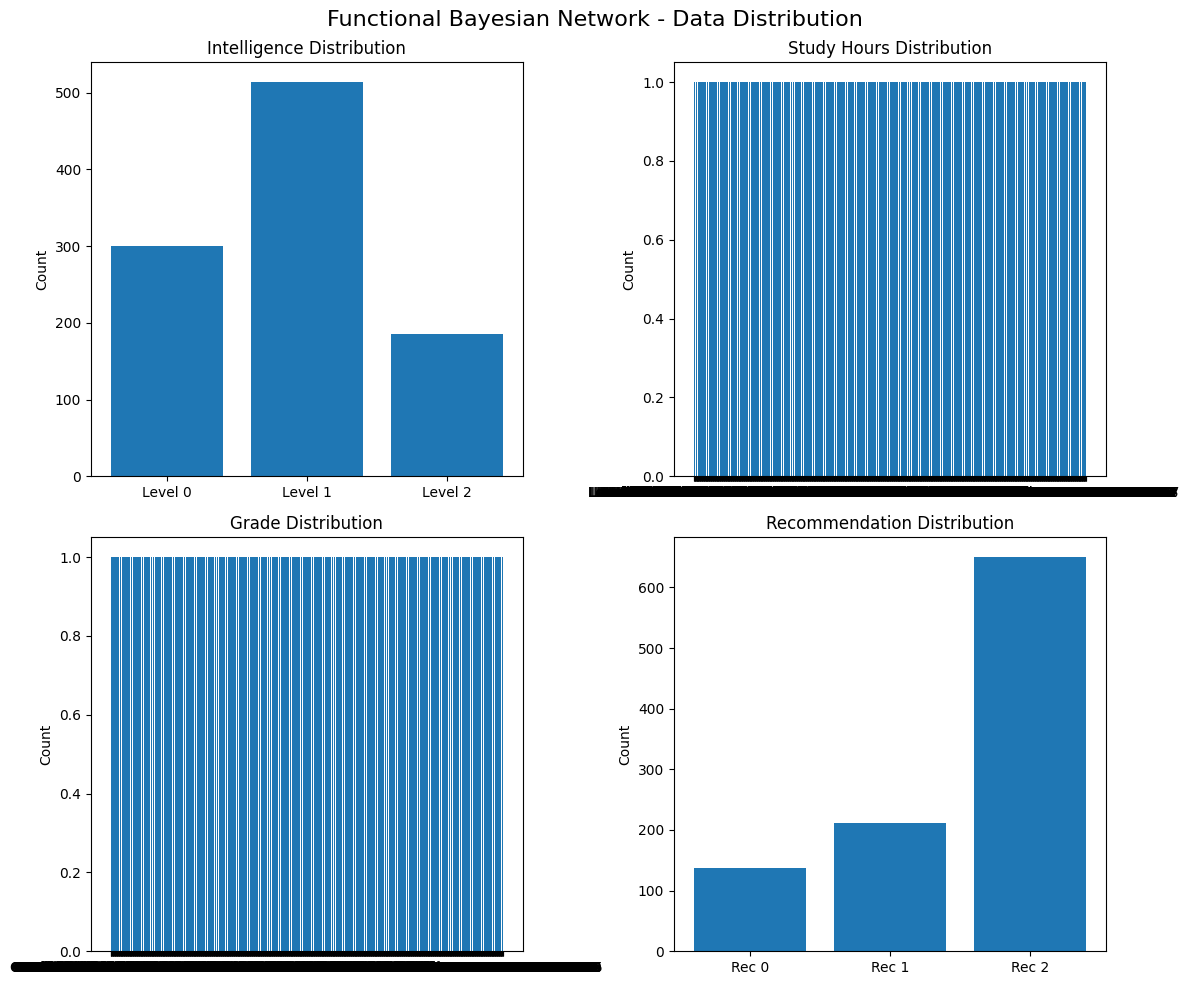

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Functional Bayesian Network - Data Distribution', fontsize=16)

# Intelligence distribution - handle variable number of categories
intelligence_counts = samples['Intelligence'].value_counts().sort_index()
intelligence_labels = [f'Level {i}' for i in intelligence_counts.index]
axes[0,0].bar(intelligence_labels, intelligence_counts.values)
axes[0,0].set_title('Intelligence Distribution')
axes[0,0].set_ylabel('Count')

# StudyHours distribution
study_counts = samples['StudyHours'].value_counts().sort_index()
study_labels = [f'Level {i}' for i in study_counts.index]
axes[0,1].bar(study_labels, study_counts.values)
axes[0,1].set_title('Study Hours Distribution')
axes[0,1].set_ylabel('Count')

# Grade distribution
grade_counts = samples['Grade'].value_counts().sort_index()
grade_labels = [f'Grade {i}' for i in grade_counts.index]
axes[1,0].bar(grade_labels, grade_counts.values)
axes[1,0].set_title('Grade Distribution')
axes[1,0].set_ylabel('Count')

# Recommendation distribution
rec_counts = samples['Recommendation'].value_counts().sort_index()
rec_labels = [f'Rec {i}' for i in rec_counts.index]
axes[1,1].bar(rec_labels, rec_counts.values)
axes[1,1].set_title('Recommendation Distribution')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Fitting a Functional BN from Data

Now let's demonstrate how to learn/fit a functional BN from observed data. We'll use the data we generated and try to recover the functional relationships.

In [12]:
params = model.fit(samples, method="SVI", 
                   optimizer=pyro.optim.Adam({"lr": 0.05}),
                   seed=42, num_steps=100)


print(params)

INFO:pgmpy:Step 0 | Loss: 7735.1738
INFO:pgmpy:Step 50 | Loss: 7734.4806


{'p_intelligence': tensor([0.3000, 0.5141, 0.1859], grad_fn=<DivBackward0>)}


## Summary

This notebook demonstrated:

1. **Defining a Functional BN**: We created a `FunctionalBayesianNetwork` with deterministic relationships using `FunctionalCPD`s

2. **Simulating Data**: We generated sample data where child nodes are deterministically computed from parent nodes

3. **Fitting a Functional BN**: We learned functional relationships from observed data and created a new model


This approach is useful when you have exact functional relationships between variables rather than probabilistic dependencies.